<a href="https://colab.research.google.com/github/VitorBZS/Avaliacao-02-AAPL-Apple-Volatilidade/blob/main/prova_02_vitor_bonilha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. EXTRAÇÃO



## Consumindo a API

In [132]:
import requests
import pandas as pd

API_KEY = "0XRTPWUZLEA2ZAG0"

url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&outputsize=compact&apikey={API_KEY}"

response = requests.get(url)
data = response.json()

print(data.keys())

if "Time Series (Daily)" not in data:
  print("Erro na API:", data)

dict_keys(['Meta Data', 'Time Series (Daily)'])


## Convertendo para DataFrame


In [133]:
time_series = data["Time Series (Daily)"]

df = pd.DataFrame.from_dict(time_series, orient = "index")

df.columns = ["open", "high", "low", "close", "volume"]

df = df.astype(float)

df.index = pd.to_datetime(df.index)

df = df.sort_index(ascending=True)

print(df.head())
df.info()

               open      high     low   close      volume
2025-12-08  278.130  279.6693  276.15  277.89  36406317.0
2025-12-09  278.160  280.0300  276.92  277.18  31753410.0
2025-12-10  277.750  279.7500  276.44  278.78  33038318.0
2025-12-11  279.095  279.5900  273.81  278.03  33247986.0
2025-12-12  277.900  279.2200  276.82  278.28  39532887.0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2025-12-08 to 2026-05-01
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    100 non-null    float64
 1   high    100 non-null    float64
 2   low     100 non-null    float64
 3   close   100 non-null    float64
 4   volume  100 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


# 2. Tratamento + Normalização

## Verificar Nulos

In [134]:
print(df.isnull().sum())

open      0
high      0
low       0
close     0
volume    0
dtype: int64


## Criando a Amplitude

In [135]:
df["amplitude"] = df["high"] - df["low"]

## Separar os preditores(X)

In [136]:
X = df[["amplitude", "volume"]]

## Normalização (StandardScaler)

In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns = X.columns, index = df.index)


<Axes: >

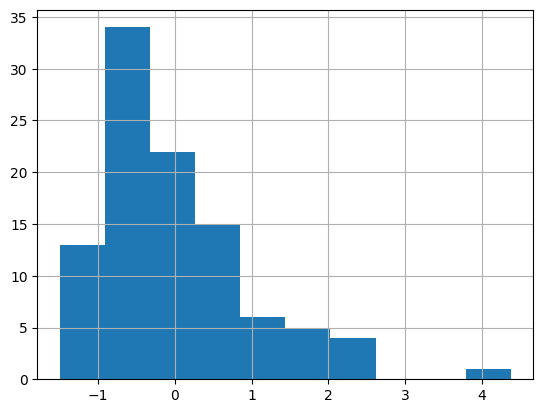

In [138]:
df.loc[:, ["amplitude" , "volume"]] = X

df["amplitude"].hist()

# Passo 3

## Criando a amplitude original

In [139]:
df["amplitude_raw"] = df["high"] - df["low"]

## Media Móvel de 100 dias

In [140]:
df["media_100"] = df["amplitude_raw"].rolling(window=100).mean()

## Criando variável (Y)

In [141]:
df["Y"] = (df["amplitude_raw"] > df["media_100"]).astype(int)
df = df.dropna()

In [142]:
print(df["Y"].value_counts())

Y
1    1
Name: count, dtype: int64
